# Project Hail Mary: The Adrian Descent
### SoC '26 KernelMind Assignment 2


In [21]:
from typing_extensions import IntVar
import numpy as np
import random
import os
import time
import pandas
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
import IPython

class ProbeEnv:

  def __init__(self, h = 1000.0, v = 0, wind_idx = 0):
    self.mprobe = 1000.0
    self.g = 13.7
    self.R = 10700000
    self.kdrag = 2.0
    self.Fthrust = 25000.0
    self.P = np.array([
    [0.65, 0.25, 0.1],   # Calm likely stays Calm
    [0.3, 0.5, 0.2],     # Gusty can go either way
    [0.1, 0.3, 0.6],     # Adrian tends to persist
    ])
    self.v = v
    self.h = h
    self.wind_idx = wind_idx


  def reset(self):
    self.h = 1000.0
    self.v = 0
    self.steps = 0
    self.wind_idx = 0
    return tuple([self.h, self.v, self.wind_idx])


  def step(self, action):
    dt = 0.1
    if(self.wind_idx == 0):
      c = 1
    elif(self.wind_idx == 1):
      c = 1.5
    elif(self.wind_idx == 2):
      c = 2.5
    k = self.kdrag*c
    v = self.v
    h = self.h
    Fdrag = k*v*abs(v)
    Fgrav = self.g*self.mprobe*(1 - h/self.R)
    Fthr = self.Fthrust*action
    Fnet = Fgrav - Fdrag - Fthr
    a = Fnet/self.mprobe
    vnew = v + dt*a
    hnew = h - vnew*dt
    self.h = hnew
    self.v = vnew
    self.steps = self.steps+1
    self.wind_idx = np.random.choice([0, 1, 2], p = self.P[self.wind_idx])
    done = False
    if(hnew<=0):
      done = True

    close = False
    if(hnew<=16.0):
      close = True


    fuel_cost = -0.3 if action == 1 else 0
    if(close == True and done == False):
       if(abs(vnew) <= 10):                                     # about to land softly
        reward = 100/(1+(abs(vnew)))
       elif(abs(vnew) >= 15):
        reward = -1.5*abs(vnew) + 6*action + fuel_cost
       else:
        reward = 0.6*fuel_cost

    elif(close == False and done == False):
        if (hnew>1000):
          reward = -800 - hnew/100
        elif(h-hnew<0 or abs(vnew)<=5 or abs(v)<=5):             # too slow or about to hover/is hovering
          reward = 100*fuel_cost + 10*(h-hnew) - 80/max(abs(vnew), 0.15)
        else:
          reward = fuel_cost
    else:
       if abs(vnew) <= 2.5:
        reward = 850 - abs(vnew*10)
       elif abs(vnew) <= 3.0:
        reward = 450
       elif(3<abs(vnew)<= 5.5):
        reward = -8
       else:
        reward = -300 - 10*abs(vnew)


    return tuple([self.h, self.v, self.wind_idx, reward, done])


---
## Design Questions — Parts 1 & 2

### Rocky's Analytics: Terminal Velocity
At terminal velocity, gravity perfectly balances drag: $F_{grav} = F_{drag}$

$$m \cdot g = k_{drag} \cdot v_{term}^2 \implies v_{term} = \sqrt{\frac{mg}{k}} = \sqrt{\frac{1000 \times 13.7}{2}} \approx 82.8 \text{ m/s}$$

The safe catch limit is ≤ 3 m/s. Terminal velocity is **~27× above the safe limit**. Without the spin-drive the probe is guaranteed to be destroyed on impact. the control problem is genuinely hard and the thrust is essential.

### Rocky's Analytics: Maximum Net Force
At $v=0$, $h \approx 0$ (worst-case gravity, no drag):

$$F_{net} = F_{grav} - F_{thrust} = 13700 - 25000 = -11300 \text{ N (upward)}$$

Yes, thrust is **strong enough to lift the probe against Adrian's gravity**. This means a naive agent could learn to perpetually fire the engine and ascend away from the target. The reward structure must explicitly penalise runaway altitude ($h > 1000$ m) to close this loophole.

### Design Question: Memory in the Storm
A Transition Probability Matrix (TPM) encodes **temporal autocorrelation** in weather. With the TPM, a Calm state transitions to another Calm state with 65% probability, meaning calm weather tends to *persist*. A pure random 3-sided die would give each state equal probability (~33%) regardless of current conditions, so Calm could jump to Adrian Gale just as easily as staying Calm.

Real weather has inertia: atmospheric systems build and dissipate gradually. The TPM captures this by making the current wind state carry **predictive information** about the next state. This is exactly the **Markov Property**: $P[S_{t+1}|S_t] \neq P[S_{t+1}]$ for a memoryless die, but with a TPM the current state is a sufficient statistic for future transitions, satisfying the MDP formalism cleanly.

In [17]:
binsh_low = np.arange(0, 20, 2)
binsh_high = np.arange(20, 1001, 20)
binsh = np.concatenate([binsh_low, binsh_high])

binsv_high = np.arange(20, 80, 1.5)
binsv_low = np.arange(0, 20, 1)
binsv = np.concatenate([binsv_low, binsv_high])

print(binsh, len(binsh))
print(binsv, len(binsv))

h_to_idx = {h:i for i,h in enumerate(binsh)}
v_to_idx = {v:i for i,v in enumerate(binsv)}


class ProbeAgent:
  def __init__(self, epsilon = 1.0, eta = 0.999, alpha = 0.085, gamma = 0.95):
    self.epsilon = epsilon
    self.eta = eta
    self.alpha = alpha
    self.gamma = gamma
    self.Q = np.zeros((60, 60 , 3, 2))


  def discretize_state(self, h, v, wind_idx):
    h_state = binsh[np.digitize(h, binsh) - 1]
    v_state = binsv[np.digitize(abs(v), binsv) - 1]
    return tuple([h_state, v_state, wind_idx])

  def choose_action(self, h, v, wind_idx):
    h_state, v_state, wind_state = self.discretize_state(h, v, wind_idx)
    Q = self.Q
    qmax = Q[h_to_idx[h_state], v_to_idx[v_state], wind_state, 0]
    j = 0
    actions = [0, 1]
    for action in actions:
      q = Q[h_to_idx[h_state], v_to_idx[v_state], wind_state, action]
      if(q > qmax):
        qmax = q
        j = action

    e = self.epsilon
    if j == 0:
      action_policy = np.random.choice([0, 1], p = [1-e/2, e/2])
    else:
      action_policy = np.random.choice([0, 1], p = [e/2, 1-e/2])

    return action_policy

  def learn(self, state, action, reward, next_state, done):
    h_s, v_s, wind_s = self.discretize_state(*state)
    h_ns, v_ns, wind_ns = self.discretize_state(*next_state)

    q_curr = self.Q[h_to_idx[h_s], v_to_idx[v_s], wind_s, action]
    a = self.alpha
    y = self.gamma
    R = reward

    if not done:
      q_max = np.max(self.Q[h_to_idx[h_ns], v_to_idx[v_ns], wind_ns])
      self.Q[h_to_idx[h_s], v_to_idx[v_s], wind_s, action] = q_curr + a*(R + y*q_max - q_curr)
    else:
      self.Q[h_to_idx[h_s], v_to_idx[v_s], wind_s, action] = q_curr + a*(R - q_curr)


[   0    2    4    6    8   10   12   14   16   18   20   40   60   80
  100  120  140  160  180  200  220  240  260  280  300  320  340  360
  380  400  420  440  460  480  500  520  540  560  580  600  620  640
  660  680  700  720  740  760  780  800  820  840  860  880  900  920
  940  960  980 1000] 60
[ 0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
 14.  15.  16.  17.  18.  19.  20.  21.5 23.  24.5 26.  27.5 29.  30.5
 32.  33.5 35.  36.5 38.  39.5 41.  42.5 44.  45.5 47.  48.5 50.  51.5
 53.  54.5 56.  57.5 59.  60.5 62.  63.5 65.  66.5 68.  69.5 71.  72.5
 74.  75.5 77.  78.5] 60


---
## Design Questions — Parts 3 & 4

### Design Question: Exploration vs. Exploitation
With $\eta = 0.999$, after 5000 episodes:
$$\epsilon = 1.0 \times 0.999^{5000} = 0.00672$$

Essentially close to **zero**. The agent is almost purely exploiting by episode 5000 with $\eta=0.999$.

This matters because decay that is **too fast** locks the agent into a suboptimal policy before it has explored enough of the state space. Decay that is **too slow** wastes late training episodes on random actions instead of refining good ones.

### Design Question: Pitfalls of the Cowardly Agent
**Huge crash penalty, tiny fuel cost:** The agent learns to hover indefinitely. Burning fuel costs only a small per-step penalty, whereas any landing attempt risks the enormous crash penalty. The rational cowardly strategy is to fire the engine continuously and never descend, a degenerate policy that never completes the mission.

**Sparse reward (only +1000 at successful terminal):** Early in training the probe almost always crashes (reward ≈ 0 or a crash penalty). With no intermediate feedback, every timestep along a good descent looks identical to every timestep along a bad one. Credit assignment across hundreds of steps is nearly impossible. There is simply no gradient pointing the agent toward safe intermediate behaviours. The agent learns almost nothing for thousands of episodes.

In [22]:
my_probe = ProbeEnv()
my_probe.reset()
my_agent = ProbeAgent()

episodes = 0
episode_rewards   = []   # total reward per episode
episode_successes = []   # 1 = soft landing (|v|<=3), 0 = crash

TOTAL_EPISODES = 18001
np.random.seed(42)

while episodes < TOTAL_EPISODES:
    my_probe.reset()
    tot_reward = 0
    done = False

    while not done:
        action    = my_agent.choose_action(my_probe.h, my_probe.v, my_probe.wind_idx)
        curr_state = (my_probe.h, my_probe.v, my_probe.wind_idx)

        result  = my_probe.step(action)
        next_st = result[:3]
        reward  = result[3]
        done    = result[4]

        tot_reward += reward
        my_agent.learn(curr_state, action, reward, next_st, done)


    success = 1 if abs(my_probe.v) <= 3.0 else 0
    episode_rewards.append(tot_reward)
    episode_successes.append(success)

    if episodes % 1000 == 0:
        recent_sr = (sum(episode_successes[-200:]) / min(200, episodes+1)) * 100
        print(f"Ep {episodes:5d} | Reward: {tot_reward:8.1f} | v_final: {my_probe.v:6.2f} m/s "
              f"| epsilon: {my_agent.epsilon:.6f} | recent success: {recent_sr:.1f}%")

    episodes += 1
    my_agent.epsilon *= my_agent.eta


print("\nTraining complete.")


Ep     0 | Reward:  -6027.2 | v_final:  25.09 m/s | epsilon: 1.000000 | recent success: 0.0%
Ep  1000 | Reward:  -1118.7 | v_final:  43.25 m/s | epsilon: 0.367695 | recent success: 0.0%
Ep  2000 | Reward:  -1242.7 | v_final:  57.43 m/s | epsilon: 0.135200 | recent success: 0.0%
Ep  3000 | Reward:   -945.0 | v_final:  30.30 m/s | epsilon: 0.049712 | recent success: 0.0%
Ep  4000 | Reward:   -708.1 | v_final:  14.63 m/s | epsilon: 0.018279 | recent success: 0.0%
Ep  5000 | Reward:   -484.7 | v_final:  11.33 m/s | epsilon: 0.006721 | recent success: 14.5%
Ep  6000 | Reward:   1162.7 | v_final:   1.27 m/s | epsilon: 0.002471 | recent success: 30.5%
Ep  7000 | Reward:    814.8 | v_final:   2.86 m/s | epsilon: 0.000909 | recent success: 42.0%
Ep  8000 | Reward:     83.3 | v_final:   3.14 m/s | epsilon: 0.000334 | recent success: 39.5%
Ep  9000 | Reward:     43.4 | v_final:   4.49 m/s | epsilon: 0.000123 | recent success: 44.0%
Ep 10000 | Reward:    -52.6 | v_final:   3.16 m/s | epsilon: 0.00

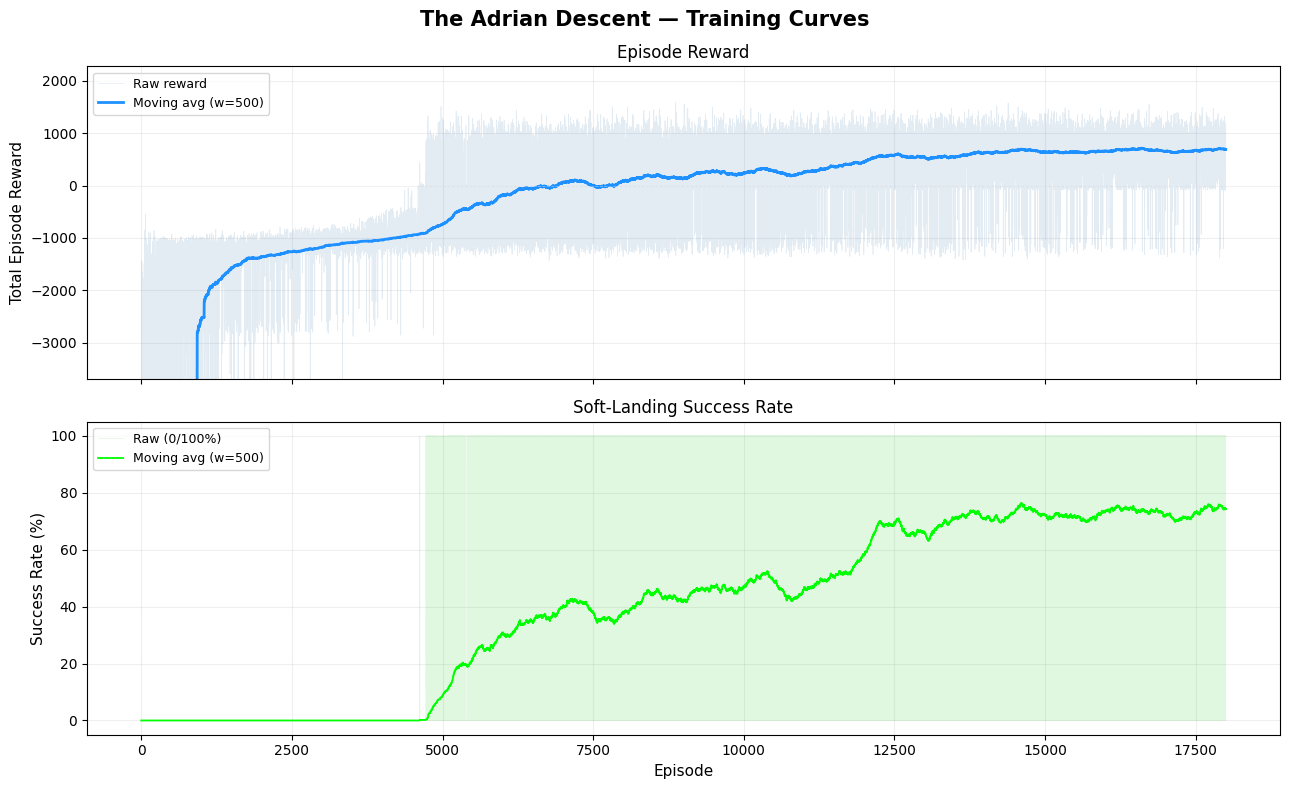

Saved learning_curve.png


In [23]:
# ANALYSIS PLOTS — Learning Curve & Success Rate


def moving_average(data, window):
    """Centred moving average with partial windows at edges."""
    return [np.mean(data[max(0, i - window):i + 1]) for i in range(len(data))]

WINDOW = 500

ma_rewards  = moving_average(episode_rewards,   WINDOW)
ma_success  = [x * 100 for x in moving_average(episode_successes, WINDOW)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.suptitle("The Adrian Descent — Training Curves", fontsize=15, fontweight='bold')

# Reward curve
ax1.plot(episode_rewards, alpha=0.15, color='steelblue', linewidth=0.5, label='Raw reward')
ax1.plot(ma_rewards, color='dodgerblue', linewidth=2.0, label=f'Moving avg (w={WINDOW})')
ax1.axhline(0, color='white', linewidth=0.6, linestyle='--', alpha=0.4)
ax1.set_ylabel('Total Episode Reward', fontsize=11)
ax1.set_title('Episode Reward', fontsize=12)
low  = np.percentile(episode_rewards, 2)   # cuts bottom 2% outliers
high = np.percentile(episode_rewards, 100)
padding = (high - low) * 0.15
ax1.set_ylim(low - padding, high + padding)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.2)

# Success rate
ax2.plot([s * 100 for s in episode_successes], alpha=0.15, color='limegreen',
         linewidth=0.5, label='Raw (0/100%)')
ax2.plot(ma_success, color='lime', linewidth=1.3, label=f'Moving avg (w={WINDOW})')
ax2.set_ylim(-5, 105)
ax2.set_ylabel('Success Rate (%)', fontsize=11)
ax2.set_xlabel('Episode', fontsize=11)
ax2.set_title('Soft-Landing Success Rate', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved learning_curve.png")


---
## Design Question — Part 5

### The Asymptote of Reward
The moving average flattens near, but never reaches the theoretical maximum for several compounding reasons:

1. **Fuel costs are unavoidable.** Every time the engine fires, a `fuel_cost = -0.3` penalty is applied. An optimal descent still requires multiple burns, so the total reward is strictly less than the terminal landing bonus alone.

2. **Terminal reward is velocity-dependent.** The soft-landing reward is `800 - |v| × 10`. Any non-zero final velocity (and $|v| > 0$ is essentially guaranteed by the continuous physics) shaves points off the maximum of 800.

3. **Stochastic wind introduces irreducible variance.** Even a perfectly learned policy occasionally faces an Adrian Gale burst that forces a suboptimal action or extra burn. The agent cannot eliminate environmental noise.

4. **Epsilon never truly reaches zero during training.** The decay $\epsilon \leftarrow \epsilon \cdot \eta$ converges to 0 asymptotically but never hits it, so a small fraction of episodes still contains exploratory (random) actions that hurt the total reward.

This asymptotic behaviour is a feature, not a bug. It is a visual diagnostic that the agent is learning. A curve that *does* touch the theoretical maximum would suggest reward hacking or a trivially easy environment.

 T+266s | ALT:    0.2m | VEL:     3.1m/s | THRUST:  [####] ON  | WIND:  Gusty 
 [ CAMERA: TARGET APPROACH (150m) ]
---------------------------------------------------------------------------
   150m +------------------------
       |
       |
       |
       |
       |
       |
       |
       |
       |
   112m +------------------------
       |
       |
       |
       |
       |
       |
       |
       |
       |
    75m +------------------------
       |
       |
       |
       |
       |
       |
       |
       |
       |
    37m +------------------------
       |
       |
       |
       |
       |
       |
       |
       |
       |
     /\
     | |
    /WW \
    ||  <-- spin-drive
 ======================= [ TAUMOEBA TARGET ] =======================

  MISSION RESULT
  Steps taken    : 267
  Final altitude : -0.032 m
  Final velocity : 1.933 m/s
  Total reward   : 1460.37

  SOFT LANDING SUCCESS — Taumoeba sample secured!


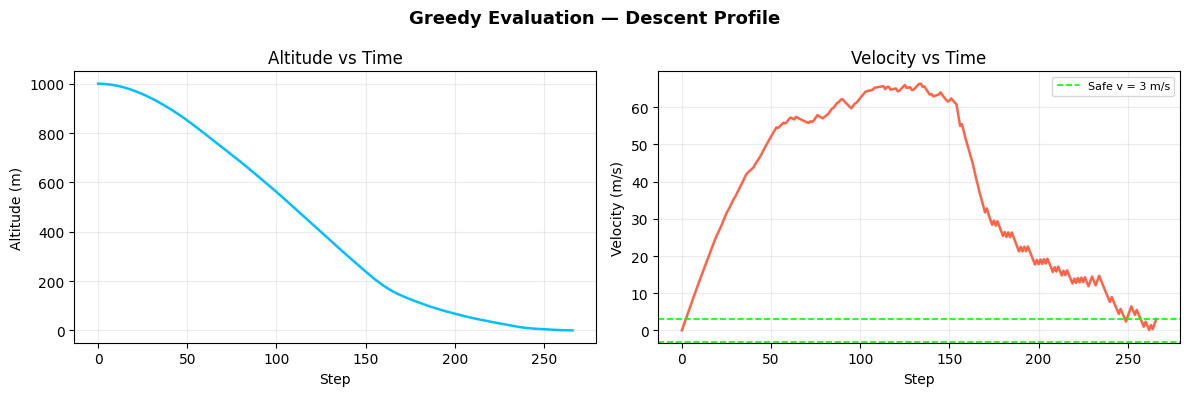

Saved eval_descent.png


In [24]:
# EVALUATION — Purely Greedy Policy (epsilon = 0)
# Runs one episode with no exploration and renders the descent.

from IPython.display import clear_output

def render_probe_ascii(h, max_h, v, action, wind, step_count, is_jupyter=False):
    """A high-framerate, pure ASCII terminal renderer."""
    if is_jupyter:
        clear_output(wait=True)
    else:
        os.system('clear' if os.name == 'posix' else 'cls')

    term_lines = 40
    if h > 150.0:
        display_max = max_h
        zoom_str = "[ CAMERA: WIDE ANGLE (1000m) ]"
    else:
        display_max = 150.0
        zoom_str = "[ CAMERA: TARGET APPROACH (150m) ]"

    pos = int((h / display_max) * term_lines)
    pos = max(0, min(term_lines, pos))

    wind_strs  = ["~ Calm ~", " Gusty ", " Adrian Gale "]
    thrust_str = " [####] ON " if action == 1 else "[     ] OFF"

    print(f" T+{step_count:03d}s | ALT: {h:6.1f}m | VEL: {v:7.1f}m/s "
          f"| THRUST: {thrust_str} | WIND: {wind_strs[wind]}")
    print(f" {zoom_str}")
    print("-" * 75)

    for i in range(term_lines, -1, -1):
        if i == pos:
            if action == 1:
                print("     /\\")
                print("     | |")
                print("    /WW \\")
                print("    ||  <-- spin-drive")
            else:
                print("     /\\")
                print("     | |")
                print("    / --\\")
                print("      ")
        else:
            if i % 10 == 0:
                print(f"  {int((i / term_lines) * display_max):4d}m +------------------------")
            else:
                print("       |")

    print(" ======================= [ TAUMOEBA TARGET ] =======================")
    time.sleep(0.04)


# Run greedy evaluation
eval_probe = ProbeEnv()
eval_probe.reset()

saved_epsilon      = my_agent.epsilon
my_agent.epsilon   = 0.0          # purely greedy, no exploration

print("=" * 55)
print("  GREEDY EVALUATION  (epsilon = 0.0)")
print("=" * 55)

done             = False
step             = 0
total_eval_reward = 0.0
eval_history     = []   # (h, v, action, wind) for post-analysis

while not done:
    action = my_agent.choose_action(eval_probe.h, eval_probe.v, eval_probe.wind_idx)
    render_probe_ascii(eval_probe.h, 1000, eval_probe.v, action,
                       eval_probe.wind_idx, step, is_jupyter=True)
    eval_history.append((eval_probe.h, eval_probe.v, action, eval_probe.wind_idx))

    result           = eval_probe.step(action)
    total_eval_reward += result[3]
    done             = result[4]
    step            += 1


my_agent.epsilon = saved_epsilon

# Final verdict
print()
print("=" * 55)
print("  MISSION RESULT")
print("=" * 55)
print(f"  Steps taken    : {step}")
print(f"  Final altitude : {eval_probe.h:.3f} m")
print(f"  Final velocity : {eval_probe.v:.3f} m/s")
print(f"  Total reward   : {total_eval_reward:.2f}")
print()
if abs(eval_probe.v) <= 3.0:
    print("  SOFT LANDING SUCCESS — Taumoeba sample secured!")
elif abs(eval_probe.v) <= 5.5:
    print("  HARD LANDING — probe damaged but structurally intact.")
else:
    print(f" CRASH — probe destroyed at {eval_probe.v:.1f} m/s.")
print("=" * 55)

# Quick eval descent plot
hs = [x[0] for x in eval_history]
vs = [x[1] for x in eval_history]
actions_hist = [x[2] for x in eval_history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Greedy Evaluation — Descent Profile", fontsize=13, fontweight='bold')

ax1.plot(hs, color='deepskyblue', linewidth=1.8)
ax1.set_xlabel('Step'); ax1.set_ylabel('Altitude (m)')
ax1.set_title('Altitude vs Time')
ax1.grid(True, alpha=0.25)

ax2.plot(vs, color='tomato', linewidth=1.8)
ax2.axhline(3,  color='lime',   linestyle='--', linewidth=1.2, label='Safe v = 3 m/s')
ax2.axhline(-3, color='lime',   linestyle='--', linewidth=1.2)
ax2.set_xlabel('Step'); ax2.set_ylabel('Velocity (m/s)')
ax2.set_title('Velocity vs Time')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('eval_descent.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved eval_descent.png")


---
## Design Question — Part 6: Bridge to the OS Scheduler

The structural isomorphism between this simulation and an OS kernel CPU scheduler is exact:

| Adrian Descent | OS CPU Scheduler |
|---|---|
| Altitude $h$, Velocity $v$ | Queue length, Average burst time |
| Adrian storm (TPM wind state) | Stochastic user I/O bursts, network arrivals |
| Thrust ON / OFF | Round Robin ↔ Shortest Job First |
| Crush penalty (high $|v|$ landing) | P90 latency spike |
| Astrophage fuel cost per burn | CPU cycles wasted on context switching |
| Soft-landing reward | High throughput + low average wait time |

In both problems the agent must learn a **reactive policy over a stochastic, continuous state space** using only the current snapshot — no lookahead, no history. The Q-table mechanics transfer directly: replace altitude/velocity bins with queue length/burst time buckets, replace the TPM wind model with an empirical workload arrival distribution, and the Bellman update equation is identical. That is why mastering tabular Q-learning here is the prerequisite for compiling an RL-driven kernel scheduler.